## GRU

### Imports

In [1]:
import os
import glob
import torch #torch es la librería principal de pytorch
import numpy as np  #librería para matemáticas
import pandas as pd #carga csv y manipulación de datos
import matplotlib.pyplot as plt
from torch import nn #nn son las neural networks de pytorch
from torch.utils.data import Dataset, DataLoader #dataset enseña a leer los archivos, dataloader se encarga de empaquetar los datos en batches
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split #divide los datos de forma aleatoria en entrenamiento y prueba
import time #para ver cuanto tarda el entrenamiento
import joblib #guardar cosas en el disco duro
import matplotlib as mpl #para configurar los gráficos

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 10

In [3]:
name = "701569_epochs_optunafullBIEN" 
BASE_DIR = r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/RNN"
RESULTS_DIR = os.path.join(BASE_DIR, "GRUact7fullBIEN_muscle", name) #para crear una carpeta con el nombre del experimento dentro de la carpeta de resultados
PTH_DIR = os.path.join(BASE_DIR, "GRUpth", f"best_emg_model_seq_GRU_{name}.pth")  #para guardar el modelo entrenado con el nombre del experimento dentro de la carpeta de modelos
RESULTS_GRU_DIR = os.path.join(BASE_DIR, "GRUact7fullBIEN_muscle", name)

os.makedirs(os.path.dirname(PTH_DIR), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
DATA_PTH = r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes"

# ---------- NOTA EN RESULTS_DIR ----------

nota = """
Experimento GRU - 701569_epochs_optunafullBIEN_condatatrain

- Datos: datos_suavizados_y_sin_anomalías
- input_len=60, output_len=30, hidden_dim=50, num_layers=2, dropout= 0.4788335110067521
- Optimizer: Adam, lr=0.001, batch_size=128, epochs=70, patience=10
- Descripción: En este train he usado de archivos: 
- He puesto y asignado de manera random
Shuffle=True
He añadidos los archivos recortados y el split es random

"""


with open(os.path.join(RESULTS_DIR, "nota.txt"), "w", encoding="utf-8") as f:
    f.write(nota)

### Configuración

In [4]:
# ---------- CONFIGURACIÓN ----------

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Cambia el número según tu GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
torch.backends.cudnn.benchmark = True  # Mejora el rendimiento en GPUs con tamaño de batch fijo
torch.backends.cudnn.deterministic = True  # Hace que el entrenamiento sea reproducible
torch.manual_seed(42)  # Fija la semilla para reproducibilidad
if device.type == 'cuda':
    torch.cuda.manual_seed(42)  # Fija la semilla para reproducibilidad en GPU
    print("Usando GPU")

Usando dispositivo: cpu


### Carga y procesado y parámetros

In [5]:
input_len = 60 # 1 segundo a 60 Hz
output_len = 30
sequence_len = input_len + output_len 
batch_size =128  #probar también con 16 y 64

#batch_size= son los ejemplos que se procesan al mismo tiempo (en paralelo). 
#en caso de que sequence_len =90, si batch_size=128, se procesan 128 secuencias de 90 muestras cada una en cada paso del entrenamiento.
#la red mirá las primeras 60 muestras de esas 128 para adivinar las 30 primeras muestras, luego pasará al siguiente paquete de 128 tras calcular errores. 

data_path = DATA_PTH

csv_files = glob.glob(
    os.path.join(DATA_PTH, "*_subject_01_cond_ASS-PRE-EXT-*_run*_ecr_fcr_final_recortado.csv")
)
csv_files = sorted(csv_files)

input_signals = []
output_signals = []
input_scalers = []
output_scalers = []

samples_to_remove = int(8 * 60)  # 8 segundos a 60 Hz

for file in csv_files:
    df = pd.read_csv(file)

    if all(col in df.columns for col in ["wrist_hand_r3_pos", "ECR_act", "FCR_act"]):

        # RECORTE AQUÍ
        df = df.iloc[samples_to_remove:].reset_index(drop=True)

        input_signal = df["wrist_hand_r3_pos"].values.astype(np.float32) #creas matriz de una columna
        emg = np.stack([df["ECR_act"], df["FCR_act"]], axis=1).astype(np.float32) #creas matriz de dos columnas

        input_signals.append(input_signal)
        output_signals.append(emg)



In [6]:
#Para saber que indice corresponde a cada archivo:
for i, file in enumerate(csv_files):
    print(f"{i}: {file}")

0: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run02_ecr_fcr_final_recortado.csv
1: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run03_ecr_fcr_final_recortado.csv
2: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run04_ecr_fcr_final_recortado.csv
3: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run01_ecr_fcr_final_recortado.csv
4: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run02_ecr_fcr_final_recortado.csv
5: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run03_ecr_fcr_final_recortado.csv
6

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import entropy

def compute_metrics(signal):
    hist, _ = np.histogram(signal, bins=50, density=True)
    hist = hist + 1e-8  # evitar log(0)

    return {
        "min": np.min(signal), "max": np.max(signal), "mean": np.mean(signal), 
        "std": np.std(signal), "var": np.var(signal), "entropy": entropy(hist)
    }

# Frecuencia de muestreo en Hz
FS = 60

# Lista para almacenar la duración de cada archivo y calcular estadísticas al final
duraciones = []

for i, file in enumerate(csv_files):
    df = pd.read_csv(file)
    
    # Calcular duración en segundos
    duracion_segundos = len(df) / FS
    duraciones.append(duracion_segundos) # Guardar en la lista

    print(f"Archivo {i}")
    print(f"Duración: {duracion_segundos:.2f} segundos")
    print("-" * 20)

    for col in ["ECR_act", "FCR_act", "wrist_hand_r3_pos"]:
        metrics = compute_metrics(df[col].values)

        print(f"{col}:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")
    print("\n")

# --- NUEVO BLOQUE AL FINAL DEL CÓDIGO ---
# Calcular la media y desviación estándar de todas las duraciones
media_duracion = np.mean(duraciones)
std_duracion = np.std(duraciones)

print("=" * 40)
print("RESUMEN DE DURACIONES DEL CONJUNTO:")
print(f"Duración total: {media_duracion:.2f} ± {std_duracion:.2f} segundos")
print("=" * 40)
        

Archivo 0
Duración: 70.90 segundos
--------------------
ECR_act:
  min: 0.0000
  max: 135.2406
  mean: 28.6802
  std: 25.8587
  var: 668.6698
  entropy: 3.2598
FCR_act:
  min: 0.0000
  max: 99.0139
  mean: 18.5704
  std: 15.6633
  var: 245.3389
  entropy: 3.1424
wrist_hand_r3_pos:
  min: -5.7106
  max: 5.6127
  mean: -0.0002
  std: 2.3092
  var: 5.3323
  entropy: 3.6835


Archivo 1
Duración: 69.97 segundos
--------------------
ECR_act:
  min: 0.0000
  max: 121.7212
  mean: 28.0713
  std: 25.0357
  var: 626.7846
  entropy: 3.3525
FCR_act:
  min: 0.0000
  max: 92.3884
  mean: 17.1279
  std: 15.3378
  var: 235.2496
  entropy: 3.1711
wrist_hand_r3_pos:
  min: -3.6971
  max: 3.8204
  mean: -0.0000
  std: 1.6180
  var: 2.6180
  entropy: 3.6935


Archivo 2
Duración: 69.82 segundos
--------------------
ECR_act:
  min: 0.0000
  max: 138.6974
  mean: 31.2806
  std: 27.9189
  var: 779.4632
  entropy: 3.3277
FCR_act:
  min: 0.0000
  max: 104.9039
  mean: 19.0074
  std: 17.2958
  var: 299.1440
  en

### División por pacientes

In [30]:
indices = np.arange(len(input_signals))
#train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
#val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)

# Asignación manual de índices,. Esta es la mejor combinacion y la que he usado para oputna 
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)

# Divide the signals based on training indices
input_signals_train = [input_signals[i] for i in train_idx] #son listas con 4 elementos, cada elemento es un vector de una dimensión
output_signals_train = [output_signals[i] for i in train_idx]

# Concatenate all training signals. las concatenamos para que el escalado se haga con la información de todo el conjunto de entrenamiento, no solo por separado por cada señal. Esto es importante para evitar fugas de datos y asegurar que el modelo vea una distribución consistente durante el entrenamiento.
all_train_inputs = np.concatenate([signal[80:].reshape(-1, 1) for signal in input_signals_train]) #el reshape se hace para transformar la fila a columna
all_train_outputs = np.concatenate([signal[80:] for signal in output_signals_train]) #no necesita reshape por que out_put_signals ya es una matriz de dos columnas (ECR y FCR)

scaler_input = MinMaxScaler() #LA FUNCIÓN min max scaler se usa para escalar los datos entre 0 y 1
scaler_output = MinMaxScaler()

scaler_input.fit(all_train_inputs)
scaler_output.fit(all_train_outputs)

print("input_len:", input_len)
print("output_len:", output_len)
print("sequence_len:", sequence_len)
print("input_len + output_len =", input_len + output_len)

# --- Inspeccionar atributos aprendidos por los scalers ---
print("=== Scaler Input (angles) ===")
print("data_min_:", scaler_input.data_min_)
print("data_max_:", scaler_input.data_max_)
print("data_range_:", scaler_input.data_range_)
print("scale_:", scaler_input.scale_)
print("min_:", scaler_input.min_)
print("feature_range:", scaler_input.feature_range)

print("\n=== Scaler Output (EMG, per channel) ===")
print("data_min_:", scaler_output.data_min_)
print("data_max_:", scaler_output.data_max_)
print("data_range_:", scaler_output.data_range_)
print("scale_:", scaler_output.scale_)
print("min_:", scaler_output.min_)
print("feature_range:", scaler_output.feature_range)

# --- Comprobar rango tras transformar (deben estar en [0,1]) ---
X_scaled = scaler_input.transform(all_train_inputs)
Y_scaled = scaler_output.transform(all_train_outputs)

print("\nTransformed input min/max:", X_scaled.min(), X_scaled.max())
print("Transformed output min per column:", Y_scaled.min(axis=0))
print("Transformed output max per column:", Y_scaled.max(axis=0))

input_len: 60
output_len: 30
sequence_len: 90
input_len + output_len = 90
=== Scaler Input (angles) ===
data_min_: [-4.840764]
data_max_: [5.096766]
data_range_: [9.9375305]
scale_: [0.10062862]
min_: [0.4871194]
feature_range: (0, 1)

=== Scaler Output (EMG, per channel) ===
data_min_: [0. 0.]
data_max_: [138.69743  104.903915]
data_range_: [138.69743  104.903915]
scale_: [0.00720994 0.00953253]
min_: [0. 0.]
feature_range: (0, 1)

Transformed input min/max: 0.0 1.0
Transformed output min per column: [0. 0.]
Transformed output max per column: [1. 1.]


### Create sequences

In [9]:
#hasta aquí, lo que hemos creado es scaler input y scaler output, que son objetos que contienen la información necesaria para escalar los datos de entrada (ángulos) y salida (EMG) respectivamente. Estos scalers se han ajustado usando todos los datos de entrenamiento concatenados, lo que garantiza que el modelo vea una distribución consistente durante el entrenamiento.
def create_sequences(indices): #He añadido meta a create sequences para ver los outputs asociados a cada secuencia y poder revertirlos después
    X, y = [], []
    meta= [] #para guardar eñ archivo exacto y de que muestra salio cada secuencia.

    for idx in indices:
        # Get raw simulation data and apply the [80:] offset
        input_seq = input_signals[idx][80:] #crea input_seq = vector 1D
        output_seq = output_signals[idx][80:] #matriz 2D con dos columnas (ECR y FCR)
        

        # Only create sequences if there are enough timesteps
        if len(input_seq) < sequence_len:
            print(f"Simulation {idx} skipped: insufficient timesteps (has {len(input_seq)}, needs {sequence_len})")
            continue

        # Scale using the global scalers (already fitted)
        input_scaled = scaler_input.transform(input_seq.reshape(-1, 1)).flatten() #Es un vector 1D
        output_scaled = scaler_output.transform(output_seq)
        
        # Generate sequences without crossing boundaries. 
        #Este for es para crear las ventanas deslizantes. Por ejemplo, si input_scaled tiene 100 muestras, y sequence_len es 90, entonces el for generará secuencias desde la muestra 0 a la 89, luego desde la muestra 1 a la 90, luego desde la muestra 2 a la 91, etc. Cada secuencia de entrada tendrá 60 muestras (input_len) y cada secuencia de salida tendrá las siguientes 30 muestras (output_len). El meta se guarda para saber exactamente de qué archivo y posición salió cada secuencia.
        for i in range(len(input_scaled) - sequence_len + 1):
            X.append(input_scaled[i:i+input_len])
            y.append(output_scaled[i+input_len:i+input_len+output_len])
            meta.append((idx, i))
    return np.array(X), np.array(y), meta

#saving the scalers
joblib.dump(scaler_input, "scaler_input.pkl")
joblib.dump(scaler_output, "scaler_output.pkl")
#loading the scalers
scaler_input = joblib.load("scaler_input.pkl")
scaler_output = joblib.load("scaler_output.pkl")

X_train, y_train, meta_train = create_sequences(train_idx)
X_val, y_val, meta_val = create_sequences(val_idx)
X_test, y_test, meta_test = create_sequences(test_idx)  # Necesitamos estos para revertir


### Dataset

In [10]:
class EMGDataset(Dataset):
    def __init__(self, X, y, scalers=None):
        self.X = torch.tensor(X).unsqueeze(-1).float() #añade esto para que tenga tres dimensiones. 
        self.y = torch.tensor(y).float() #torch los convierte a tensores, que es el formato que usa pytorch para los datos. unsqueeze(-1) añade una dimensión extra al final, lo que hace que cada muestra de entrada tenga forma (input_len, 1) en lugar de (input_len,). Esto es necesario porque las capas recurrentes de pytorch esperan una entrada con tres dimensiones: (batch_size, sequence_length, num_features). En este caso, num_features es 1 porque cada muestra de entrada es un solo ángulo.

    def __len__(self): #funcion para saber cuantas secuencias en total hay en el dataset.
        return len(self.X)

    def __getitem__(self, idx): #funcion que proporciona un ejemplo especifico del dataset.
        return self.X[idx], self.y[idx]

train_loader = DataLoader(EMGDataset(X_train, y_train), batch_size=batch_size, shuffle=True) #He probado con shuffle=False que es como lo tenía Nuria.

val_loader = DataLoader(EMGDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(EMGDataset(X_test, y_test), batch_size=batch_size)

batch = next(iter(train_loader))
X_batch, y_batch = batch
print("Batch shapes: X=", X_batch.shape, " y=", y_batch.shape)
print("Number of batches: train, val, test=", len(train_loader), len(val_loader), len(test_loader))
print("X_batch dtype/min/max:", X_batch.dtype, X_batch.min().item(), X_batch.max().item())
print("y_batch dtype/min/max:", y_batch.dtype, y_batch.min().item(), y_batch.max().item())

Batch shapes: X= torch.Size([128, 60, 1])  y= torch.Size([128, 30, 2])
Number of batches: train, val, test= 210 30 44
X_batch dtype/min/max: torch.float32 0.013496816158294678 1.0
y_batch dtype/min/max: torch.float32 0.0 1.0


### Modelo

In [11]:

#Hasta aqui ya tenemos todo el dataset cargado, escalado y empaquetado en batches
#ahora vamos a definir la red
#n um_layers=2, la primera capa procesa los angulos de entrada y pasa su salida a la segunda capa.
#drop_out es el porcentaje de neuronas que se apagan aleatoriamente durante el entrenamiento.
class SeqGRUModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=50, output_dim=2, num_layers=2, dropout_prob=0.4788335110067521):
        super(SeqGRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob)
        # Map the last hidden state to (output_len * output_dim) total outputs
        self.fc = nn.Linear(hidden_dim, output_len * output_dim) #caoa fully connected . En este caso sería una capa nn.linear(50, 30*2), una capa que reciba 50 numeros de entradas que es el resumen de la GRU, y que los transforme en 60 numeros de salida.
        self.dropout = nn.Dropout(dropout_prob) #que aoaga el 20% de las neuronas de forma aleatoria.
        
    def forward(self, x): # Relaciona input con output. Aqui defines las layers
        # x: (batch_size, input_len, 1)
        _, hidden = self.gru(x)               # hidden: (num_layers, batch_size, hidden_dim) 1 layer,
        #self.gru(x) te da dos paquetes de información. solo te intersa el hidden, que es el resumen de la información de toda la secuencia.
        #hidden= [2,16,50], siendo 2 la memoria de la capa 1 y la memoria de la capa 2, 16 el batch size y 50 el hidden dim.
        hidden_last = hidden[-1]              # (batch_size, hidden_dim), descartas las memorias de las capas anteriores y te quedas solo con la última capa, que es la que tiene el resumen final de la secuencia.
        hidden_last = self.dropout(hidden_last) #la segunda. Aplicas el dropout
        out = self.fc(hidden_last)            # (batch_size, output_len * output_dim), es decir [16, 60] tengo 16 filas y para cada una, una tira plana con 60 predicciones numéricas.
        out = out.view(-1, output_len, 2)     # (batch_size, output_len, 2) [-1,30, 2] porque cada muestra de salida tiene 30 pasos de tiempo y 2 canales (ECR y FCR)
        return out
    #out será [16, 30, 2]

model = SeqGRUModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #Adam es un optimizador que ajusta los pesos de la red para minimizar la función de pérdida. lr es la tasa de aprendizaje, que controla cuánto se ajustan los pesos en cada paso.
criterion = nn.MSELoss()




Resumen de lo anterior

[16,60,1 ]---- GRU---- [2,16,50]---- [-1]---- [16,50] ----Linear---- [16,60]------View----[16,30,2]

### Comprobaciones

In [12]:
#overlap entre índices
print("Train indices:", train_idx)
print("Validation indices:", val_idx)
print("Test indices:", test_idx)


Train indices: [ 5  2  1 11  4  7  3  6]
Validation indices: [10  0]
Test indices: [9 8]


### Entrenamiento

In [13]:
patience = 10 #margen de 10 épocas seguidas sin que mejore el error de validation.
counter = 0 #el counter que va sumando cuantas epocas sigue sin mejorar el error de validación.
best_val_loss = float('inf') #es un valor incial infinito para que asi el modelo al principio se guarde

train_losses = []
val_losses = []

start_time = time.time() #cronómetro inicial para medir el tiempo de entrenamiento

for epoch in range(70): #cambiar las epochs a 150 que era como Nuria las tenía configuradas. 
    model.train()
    total_loss = 0 #contador para acumular la pérdida total de entrenamiento en esta época
    for batch_X, batch_y in train_loader: #el bucle se repite hasta que haya visto todos los paquetes de la epoca
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
       #matemática de la GRU
        pred = model(batch_X) #calcula la prediccion basado en angulos de entrada.
        loss = criterion(pred, batch_y) #calcula el error entre la prediccion y la señal real de EMG. El objetivo del entrenamiento es minimizar esta pérdida.
        optimizer.zero_grad() #borra los gradientes acumulados de la iteración anterior para que no se sumen a los nuevos gradientes calculados en esta iteración.
        loss.backward() #backpropagation, calcula los gradientes de la pérdida con respecto a los pesos de la red.
        optimizer.step() #ajusta los pesos de la red usando los gradientes calculados en el paso anterior.
        total_loss += loss.item() #suma el error de este paquete al acumulado de la época para luego sacar el promedio.

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)
    #examen de validacion:
    model.eval() #activa el modo evlauacion y apaga el entrenamiento
    val_loss = 0 #para calcular la pérdida de validación
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_pred = model(val_X)
            val_loss += criterion(val_pred, val_y).item()
   
    val_loss /= len(val_loader)
    val_losses.append(val_loss) #aqui se van guardando todas las perdidas por cada epoch

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Batch Loss = {loss.item():.4f}")

    # Visualization of predictions for debugging
    #plt.plot(batch_y[0].cpu().numpy(), label="True")  # Replace y_batch with batch_y
    #plt.plot(pred[0].detach().cpu().numpy(), label="Predicted")
    #plt.legend()
    #plt.show()

    # Early stopping
    mod_guardado_con_early_stopping = False
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), PTH_DIR) #va guardando el mejor hasta el momento.
        print("✅ Modelo guardado")
        counter = 0
        # Guarda la mejor epoch cada vez que mejora
        with open(os.path.join(RESULTS_DIR, "early_stopping_epoch.txt"), "w") as f:
            f.write(str(epoch + 1))  # +1 para que sea 1-based
    else:
        counter += 1
        if counter >= patience:
            print("⏳ Early stopping")
            end_time = time.time()
            elapsed_time = end_time - start_time
            print(f"⏱️ Tiempo de entrenamiento: {elapsed_time:.2f} segundos")
            with open(os.path.join(RESULTS_DIR, "training_time.txt"), "w") as f:
                f.write(f"Training time (s): {elapsed_time:.2f}")
            break

Epoch 1: Train Loss = 0.0278, Val Loss = 0.0242, Batch Loss = 0.0218
✅ Modelo guardado
Epoch 2: Train Loss = 0.0194, Val Loss = 0.0196, Batch Loss = 0.0185
✅ Modelo guardado
Epoch 3: Train Loss = 0.0182, Val Loss = 0.0186, Batch Loss = 0.0186
✅ Modelo guardado
Epoch 4: Train Loss = 0.0176, Val Loss = 0.0185, Batch Loss = 0.0159
✅ Modelo guardado
Epoch 5: Train Loss = 0.0171, Val Loss = 0.0183, Batch Loss = 0.0175
✅ Modelo guardado
Epoch 6: Train Loss = 0.0166, Val Loss = 0.0181, Batch Loss = 0.0158
✅ Modelo guardado
Epoch 7: Train Loss = 0.0160, Val Loss = 0.0181, Batch Loss = 0.0164
✅ Modelo guardado
Epoch 8: Train Loss = 0.0151, Val Loss = 0.0180, Batch Loss = 0.0140
✅ Modelo guardado
Epoch 9: Train Loss = 0.0148, Val Loss = 0.0179, Batch Loss = 0.0168
✅ Modelo guardado
Epoch 10: Train Loss = 0.0145, Val Loss = 0.0179, Batch Loss = 0.0158
Epoch 11: Train Loss = 0.0143, Val Loss = 0.0176, Batch Loss = 0.0151
✅ Modelo guardado
Epoch 12: Train Loss = 0.0142, Val Loss = 0.0176, Batch Los

### Guardado de datos

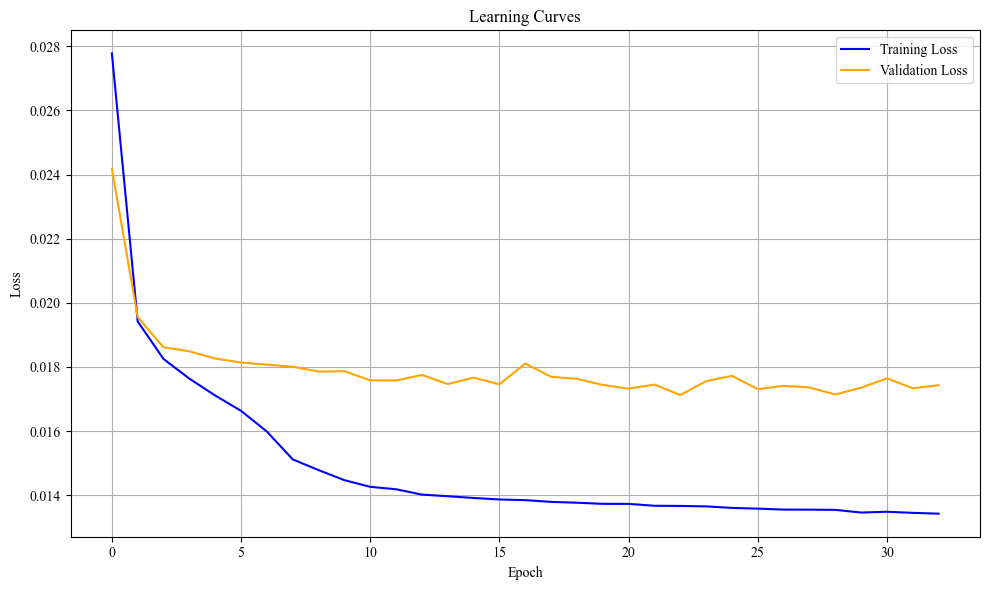

In [23]:
# Guardando los datos para plots en otro file de las curvas de aprendizaje
np.save(os.path.join(RESULTS_DIR, f"train_losses_{name}.npy"), np.array(train_losses))
np.save(os.path.join(RESULTS_DIR, f"val_losses_{name}.npy"), np.array(val_losses))

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.title("Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"learning_curve_{name}.png"))
plt.show()

#para intentar que el validation loss baje puedo probar a aumentar el batch size

### Evaluación y error pero con datos normalizados 

C:\Users\adria\AppData\Local\Temp\ipykernel_26780\3609751423.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PTH_DIR))



📊 Test Prediction (NORMALIZED):
MAE: 0.0950, RMSE: 0.1277, R²: 0.2280
Correlation (normalized) ECRL: 0.5631
Correlation (normalized) FCR: 0.4400
Correlation mean (normalized): 0.5016


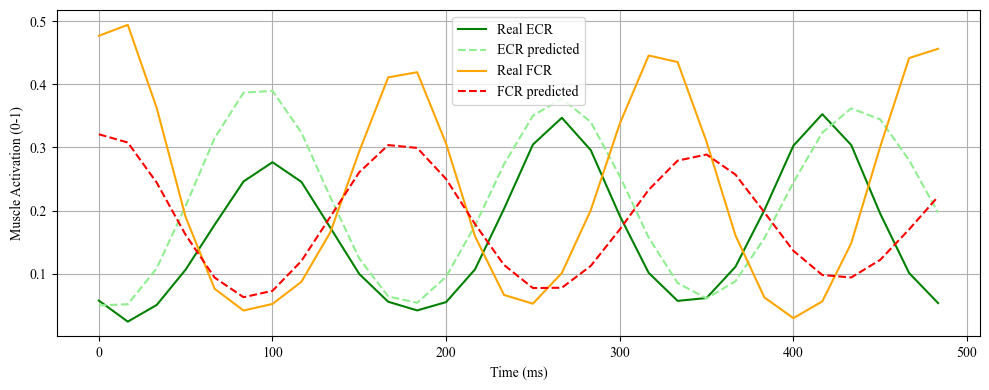

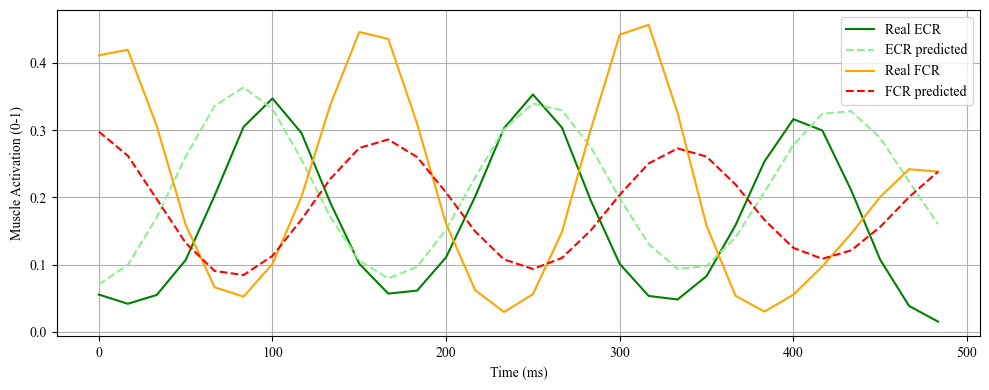

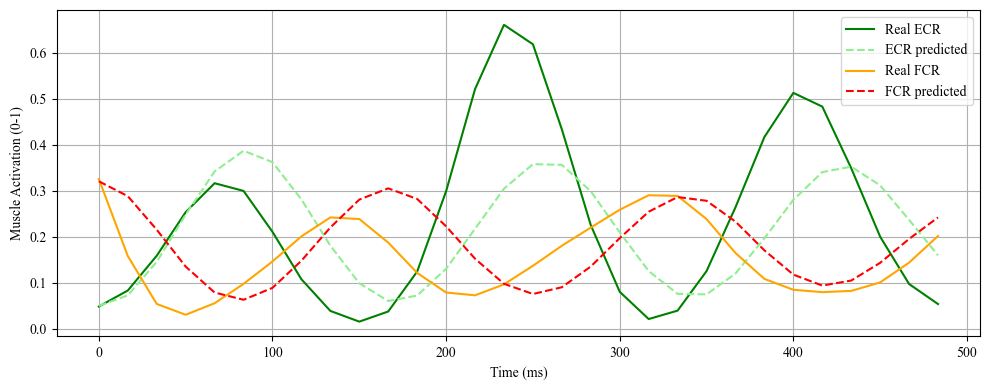

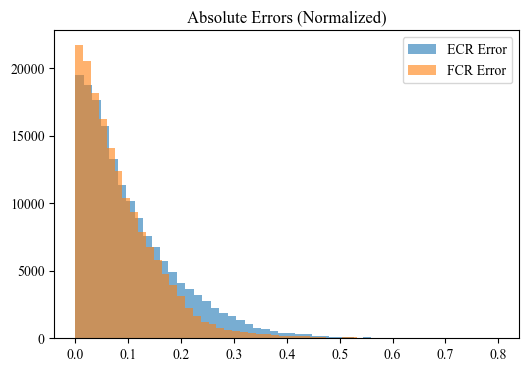

X_train shape: (26851, 60), y_train shape: (26851, 30, 2)
X_val shape: (3796, 60), y_val shape: (3796, 30, 2)
y_train min: 0.0, max: 1.0
Input scaler min: [-4.840764], max: [5.096766]
Output scaler min: [0. 0.], max: [138.69743  104.903915]

📊 Train Prediction (NORMALIZED):
MAE: 0.0832, RMSE: 0.1141, R²: 0.4087
Correlation (normalized) ECRL: 0.6598
Correlation (normalized) FCR: 0.6244
Correlation mean (normalized): 0.6421


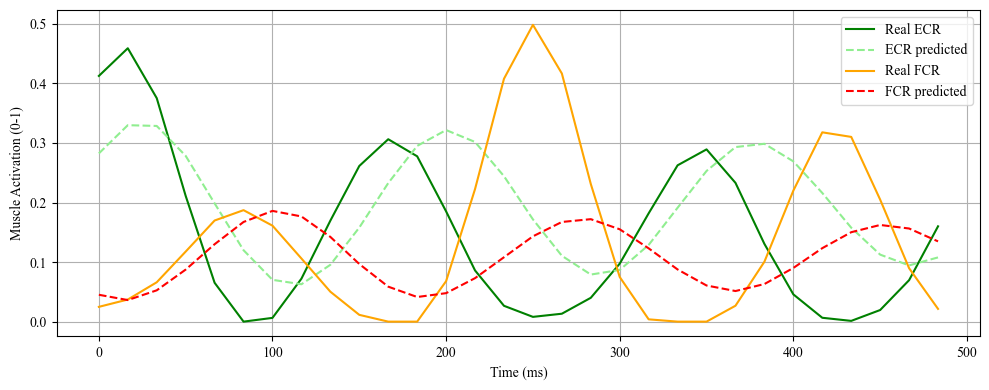

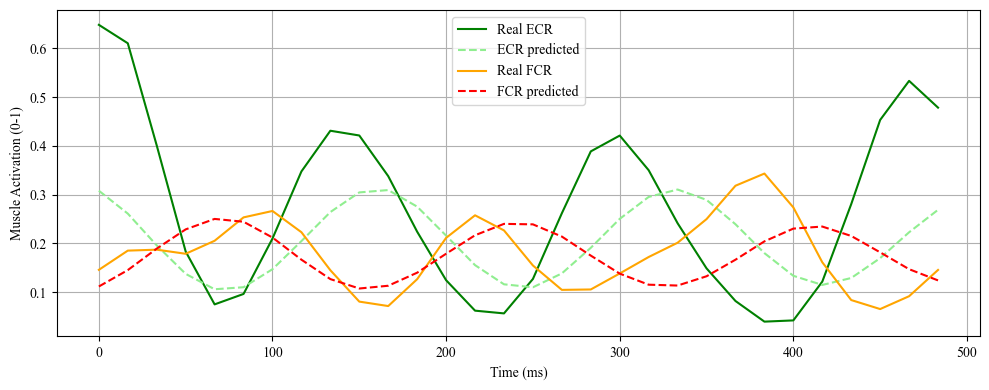

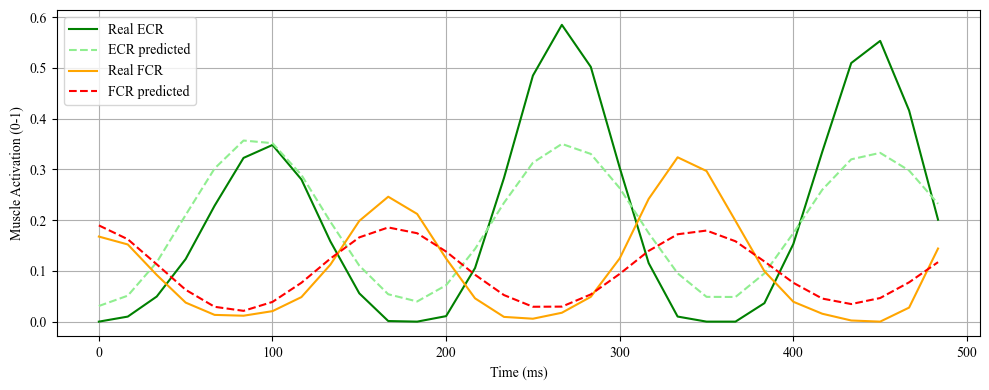

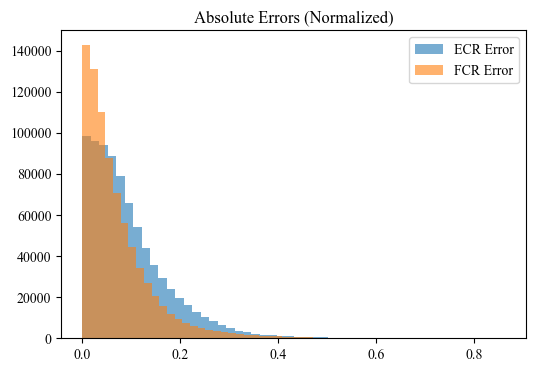


📊 Validation Prediction (NORMALIZED):
MAE: 0.0985, RMSE: 0.1310, R²: 0.4031
Correlation (normalized) ECRL: 0.6808
Correlation (normalized) FCR: 0.6023
Correlation mean (normalized): 0.6416


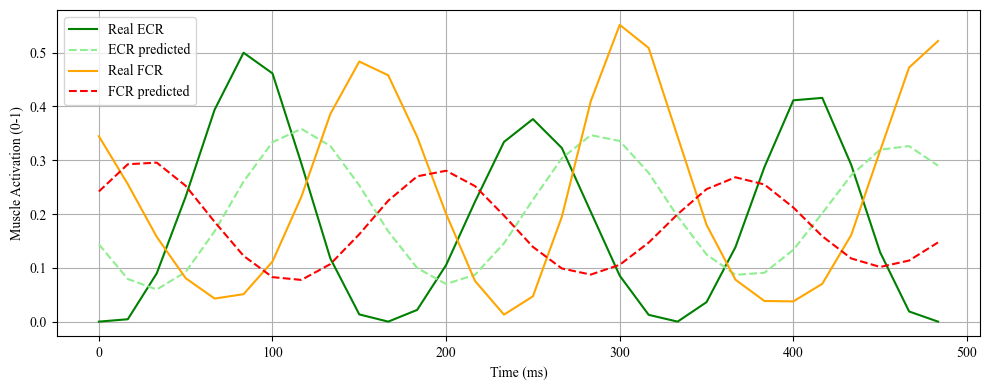

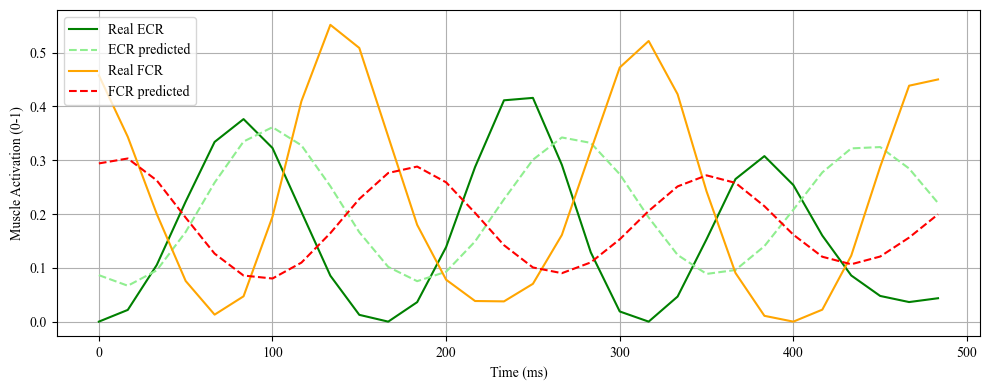

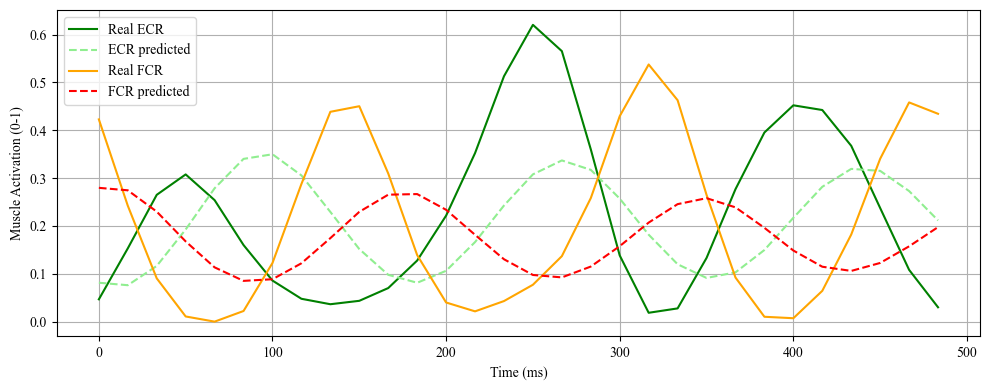

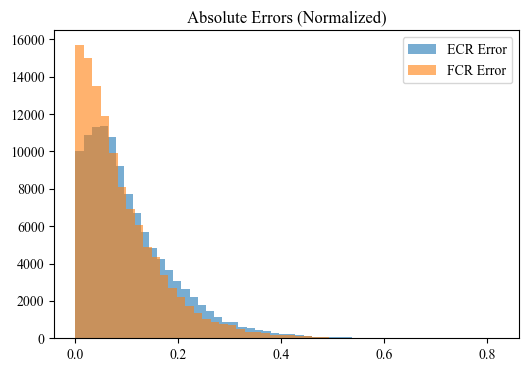

In [ ]:
def evaluate_and_plot(loader, title="Evaluación"):
    model.eval()
    all_preds, all_trues = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(y_batch.cpu().numpy())

    y_pred_norm = np.concatenate(all_preds) #(Total_de_secuencias, 30, 2)
    y_true_norm = np.concatenate(all_trues) 



    flat_pred = y_pred_norm.reshape(-1, 2) #lo transforma a una matriz de dos columnas, ECR y FCR.
    flat_true = y_true_norm.reshape(-1, 2)

    # Métricas
    mae = mean_absolute_error(flat_true, flat_pred)
    rmse = np.sqrt(mean_squared_error(flat_true, flat_pred))
    r2 = r2_score(flat_true, flat_pred)

    corr_ecr = np.corrcoef(flat_true[:, 0], flat_pred[:, 0])[0, 1]
    corr_fcr = np.corrcoef(flat_true[:, 1], flat_pred[:, 1])[0, 1]
    corr_mean = np.nanmean([corr_ecr, corr_fcr])

    print(f"\n📊 {title} Prediction (NORMALIZED):")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    print(f"Correlation (normalized) ECRL: {corr_ecr:.4f}")
    print(f"Correlation (normalized) FCR: {corr_fcr:.4f}")
    print(f"Correlation mean (normalized): {corr_mean:.4f}")


    def plot_example(i):
        y_real_sample = y_true_norm[i] 
        y_pred_sample = y_pred_norm[i]

        t = np.arange(output_len) * (1000 / 60)  # 60Hz

        plt.figure(figsize=(10, 4))
      
        plt.plot(t, y_real_sample[:, 0], label='Real ECR', color='green')
        plt.plot(t, y_pred_sample[:, 0], '--', label='ECR predicted', color='lightgreen')
        plt.plot(t, y_real_sample[:, 1], label='Real FCR', color='orange')
        plt.plot(t, y_pred_sample[:, 1], '--', label='FCR predicted', color='red')
        
        plt.xlabel("Time (ms)")
        plt.ylabel("Muscle Activation (0-1)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    
    for i in [0, 10, 30]: #son las secuencias 0, 10 y 30. Cada secuencia contenia 60 de input y 30 de output para cada muscle.
        if i < len(y_true_norm):
            plot_example(i)

    errors = np.abs(flat_pred - flat_true)
    plt.figure(figsize=(6, 4))
    plt.hist(errors[:, 0], bins=50, alpha=0.6, label="ECR Error")
    plt.hist(errors[:, 1], bins=50, alpha=0.6, label="FCR Error")
    plt.legend()
    plt.title("Absolute Errors (Normalized)")
    plt.show()

    return y_pred_norm, y_true_norm
# Evaluación
model.load_state_dict(torch.load(PTH_DIR))
y_pred_test, y_true_test = evaluate_and_plot(test_loader, "Test")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

print(f"y_train min: {y_train.min()}, max: {y_train.max()}")

print(f"Input scaler min: {scaler_input.data_min_}, max: {scaler_input.data_max_}")
print(f"Output scaler min: {scaler_output.data_min_}, max: {scaler_output.data_max_}")

y_pred_train, y_true_train = evaluate_and_plot(train_loader, "Train")
y_pred_val, y_true_val = evaluate_and_plot(val_loader, "Validation")


np.save("test_indices.npy", test_idx)
np.save("train_indices.npy", train_idx)
np.save("val_indices.npy", val_idx)


### Gráficas de errores

In [ ]:


def plot_error_analysis(y_pred, y_true, title="Test", results_dir=None, run_name=None):
    """
    Grafica el MAE por cada paso de tiempo futuro y el análisis mu/sigma.
    """

    r_dir = results_dir if results_dir is not None else RESULTS_DIR
    r_name = run_name if run_name is not None else name

    # 1. Error absoluto medio por timestep
    errors_by_step = np.abs(y_pred - y_true)
    mean_errors = errors_by_step.mean(axis=0)
    t = np.arange(output_len) # 60Hz
    
    plt.figure(figsize=(10, 4))
    plt.plot(t, mean_errors[:, 0], label="ECRL", color='purple')
    plt.plot(t, mean_errors[:, 1], label="FCR", color='brown')
    plt.title(f"Mean error per future timestep ({title})", fontsize=16)
    plt.xlabel("Timestep", fontsize=14)
    plt.ylabel("Mean Absolute Error (MAE)", fontsize=14)
    plt.legend(loc="upper right", fontsize=12, frameon=True)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(r_dir, f"Error_by_timestep_{title}_{r_name}.png"))
    plt.show()

    # 2. Distribución del error (Media y desviación estándar por timestep)
    errors = y_pred - y_true
    mu = errors.mean(axis=0) #este es el error directo, punto por punto
    sigma = errors.std(axis=0)
    
    plt.figure(figsize=(10, 4))
    for i, label in enumerate(["ECRL", "FCR"]):
        color = 'purple' if i == 0 else 'brown'
        plt.plot(t, mu[:, i], label=f"μ {label}", color=color)
        plt.fill_between(t, mu[:, i] - sigma[:, i], mu[:, i] + sigma[:, i], alpha=0.2, label=f"μ±σ {label}")
        
    plt.xlabel("Timestep", fontsize=14)
    plt.ylabel("Error", fontsize=14)
    plt.legend(loc="upper right", fontsize=10, frameon=True)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(r_dir, f"Error_mu_sigma_{title}_{r_name}.png"))
    plt.show()


def plot_input_output_pair(X_data, y_true_data, y_pred_data, index=0, title="Test", results_dir=None, run_name=None):
    """
    Grafica la secuencia del ángulo cinemático de entrada (pasado) frente a las activaciones de salida (futuro)
    """
    r_dir = results_dir if results_dir is not None else RESULTS_DIR
    r_name = run_name if run_name is not None else name

    input_raw = X_data[index]
    input_real = scaler_input.inverse_transform(input_raw.reshape(-1, 1)).flatten()
    
    pred_emg = y_pred_data[index]
    real_emg = y_true_data[index]

    t_input = np.arange(-input_len, 0) * (1000 / 60)
    t_output = np.arange(0, output_len) * (1000 / 60)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(t_input, input_real, color='blue', label='Angles', linewidth=1.5)
    ax1.set_ylabel("Wrist Flexion-Extension Angles (Degrees)", color='blue', fontsize=14)
    ax1.set_xlabel("Time (ms)", fontsize=14)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(False)

    ax2 = ax1.twinx()
    offset = 1.2 

    ax2.plot(t_output, pred_emg[:, 0] + offset, 'purple', linestyle='--', label='ECR predicted')
    ax2.plot(t_output, real_emg[:, 0] + offset, 'purple', label='ECR real', alpha=0.6)

    ax2.plot(t_output, pred_emg[:, 1], 'brown', linestyle='--', label='FCR predicted')
    ax2.plot(t_output, real_emg[:, 1], 'brown', label='FCR real', alpha=0.6)
    ax2.set_ylabel("Muscle Activation (0-1)", color='black', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='black')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(r_dir, f"Input_output_pair_{title}_{index}_{r_name}.png"))
    plt.show()
#la ultima gráfica he añadido un offset para que no se solapen abajo las activaciones y se pueda ver mejor.




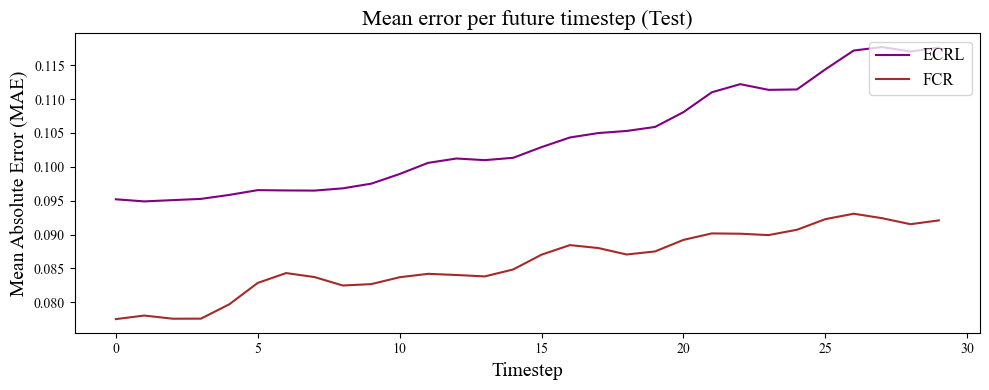

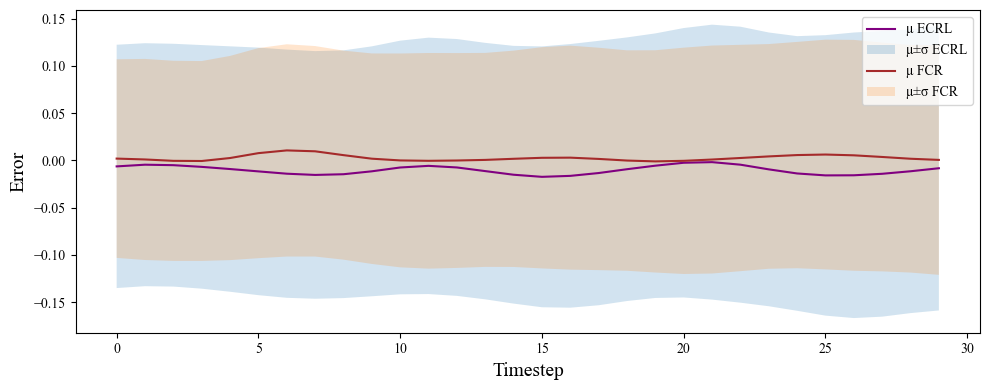

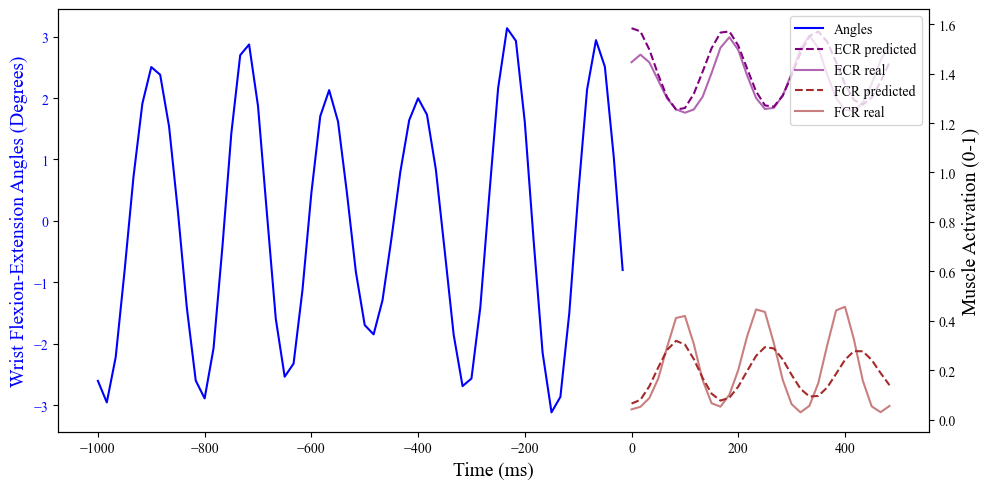

In [26]:
# === ANÁLISIS DE TEST ===
plot_error_analysis(y_pred_test, y_true_test, title="Test")
plot_input_output_pair(X_test, y_true_test, y_pred_test, index=5, title="Test")



### Evaluación y error


📊 Test EMG Prediction:
MAE: 11.7279, RMSE: 16.0985, R²: 0.2281


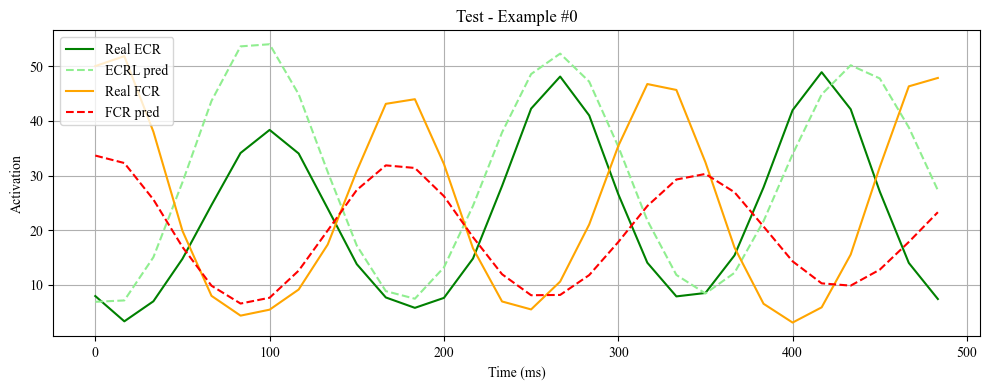

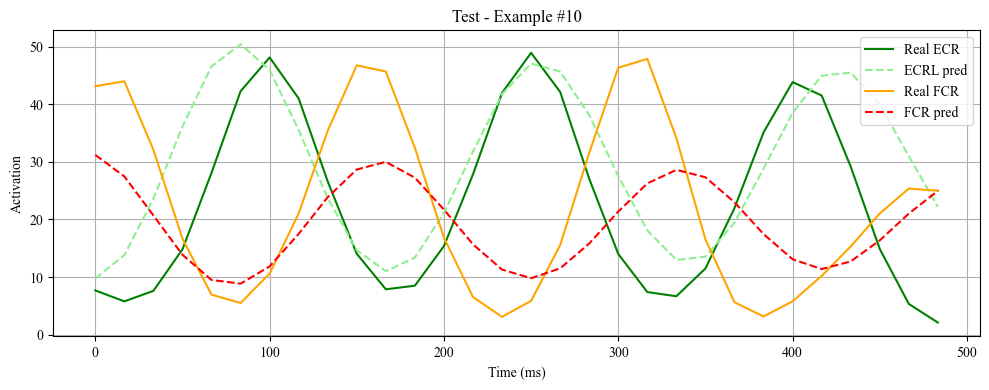

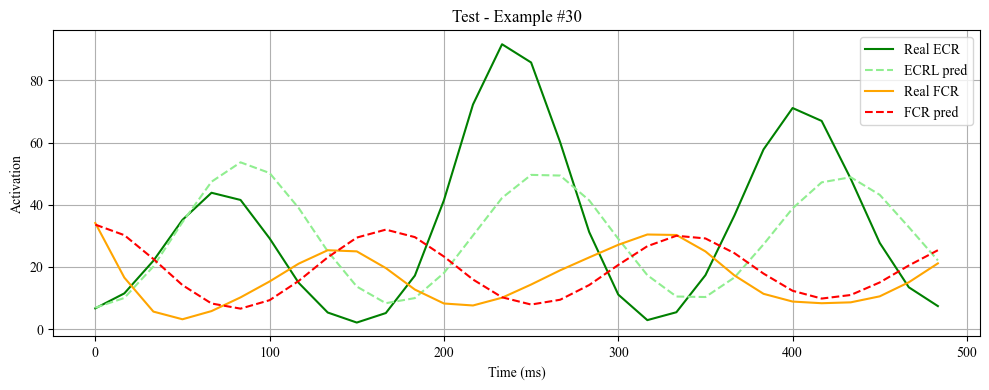

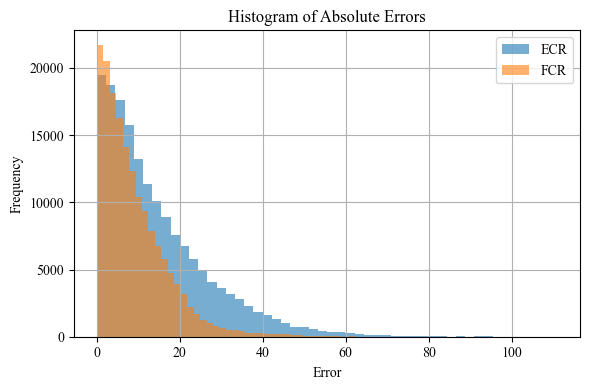

In [ ]:
# ---------- EVALUACIÓN ----------
def evaluate_and_plot(loader, title="Evaluación"):
    model.eval()
    all_preds, all_trues = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(y_batch.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_trues)

    # Use global scaler for inverse transformation
    pred_inv = scaler_output.inverse_transform(y_pred.reshape(-1, 2)).reshape(y_pred.shape)
    true_inv = scaler_output.inverse_transform(y_true.reshape(-1, 2)).reshape(y_true.shape)

    mae = mean_absolute_error(true_inv.reshape(-1, 2), pred_inv.reshape(-1, 2))
    rmse = np.sqrt(mean_squared_error(true_inv.reshape(-1, 2), pred_inv.reshape(-1, 2)))
    r2 = r2_score(true_inv.reshape(-1, 2), pred_inv.reshape(-1, 2))


    print(f"\n📊 {title} EMG Prediction:")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")




    def plot_example(i):
        y_real = true_inv[i]
        y_pred_plot = pred_inv[i]

        t = np.arange(output_len) * (1000 / 60)  # 60Hz

        plt.figure(figsize=(10, 4))
        plt.plot(t, y_real[:, 0], label='Real ECR', color='green')
        plt.plot(t, y_pred_plot[:, 0], '--', label='ECRL pred', color='lightgreen')
        plt.plot(t, y_real[:, 1], label='Real FCR', color='orange')
        plt.plot(t, y_pred_plot[:, 1], '--', label='FCR pred', color='red')
        plt.title(f"{title} - Example #{i}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Activation")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    for i in [0,10,30]:
        if i < len(true_inv):
            plot_example(i)

    # Histograma de errores
    errors = np.abs(pred_inv - true_inv)

    plt.figure(figsize=(6, 4))
    plt.hist(errors[:, :, 0].flatten(), bins=50, alpha=0.6, label="ECR")
    plt.hist(errors[:, :, 1].flatten(), bins=50, alpha=0.6, label="FCR")
    plt.title("Histogram of Absolute Errors")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return y_pred, y_true


# Evaluación
y_pred, y_true = evaluate_and_plot(test_loader, "Test")

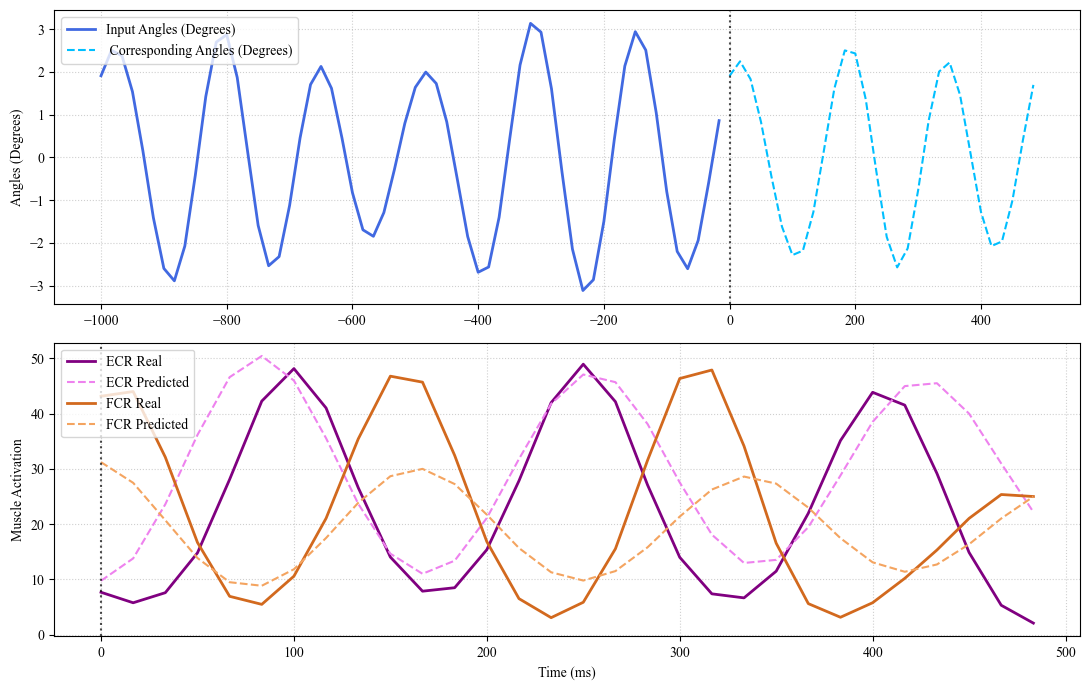

In [ ]:
def plot_input_output_clean(sample_idx=0, title="Test"):
    """
    Genera un gráfico con dos subplots perfectamente alineados en el tiempo:
    1. Subplot Superior: Ángulo de la muñeca (Input Pasado + Input Futuro correspondiente).
    2. Subplot Inferior: Activaciones musculares (EMG Real vs Predicho) en el horizonte futuro.
    """
    fs = 60  # Hz (Frecuencia de muestreo de tu laboratorio)
    
    if title.lower() == "test":
        meta_data = meta_test
    elif title.lower() == "val":
        meta_data = meta_val
    else:
        meta_data = meta_train
        
    if sample_idx >= len(meta_data):
        print(f"❌ El índice {sample_idx} supera el tamaño de los datos de {title} (max: {len(meta_data)-1})")
        return

    signal_idx, start_idx = meta_data[sample_idx]

    full_raw_input = input_signals[signal_idx][80:]
    
    input_past_raw = full_raw_input[start_idx : start_idx + input_len]
    input_future_raw = full_raw_input[start_idx + input_len : start_idx + input_len + output_len]


    pred_emg_sample = scaler_output.inverse_transform(y_pred[sample_idx].reshape(-1, 2))
    true_emg_sample = scaler_output.inverse_transform(y_true[sample_idx].reshape(-1, 2))

    t_past = np.arange(-input_len, 0) * (1000 / fs)
    t_future = np.arange(0, output_len) * (1000 / fs)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
    
    axes[0].plot(t_past, input_past_raw, color="royalblue", linewidth=2, label="Input Angles (Degrees)")
    axes[0].plot(t_future, input_future_raw, color="deepskyblue", linewidth=1.5, linestyle="--", label=" Corresponding Angles (Degrees)")
    axes[0].axvline(0, color="black", linestyle=":", alpha=0.7) # Línea del "Presente"
    
    axes[0].set_ylabel("Angles (Degrees)", fontsize=10)
    axes[0].legend(loc="upper left")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    axes[1].plot(t_future, true_emg_sample[:, 0], color="purple", linewidth=2, label="ECR Real")
    axes[1].plot(t_future, pred_emg_sample[:, 0], color="violet", linewidth=1.5, linestyle="--", label="ECR Predicted")
    axes[1].plot(t_future, true_emg_sample[:, 1], color="chocolate", linewidth=2, label="FCR Real")
    axes[1].plot(t_future, pred_emg_sample[:, 1], color="sandybrown", linewidth=1.5, linestyle="--", label="FCR Predicted")
    axes[1].axvline(0, color="black", linestyle=":", alpha=0.7) # Línea del "Presente"
    
    axes[1].set_xlabel("Time (ms)", fontsize=10)
    axes[1].set_ylabel("Muscle Activation", fontsize=10)
    axes[1].legend(loc="upper left")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_input_output_clean(sample_idx=10, title="Test")

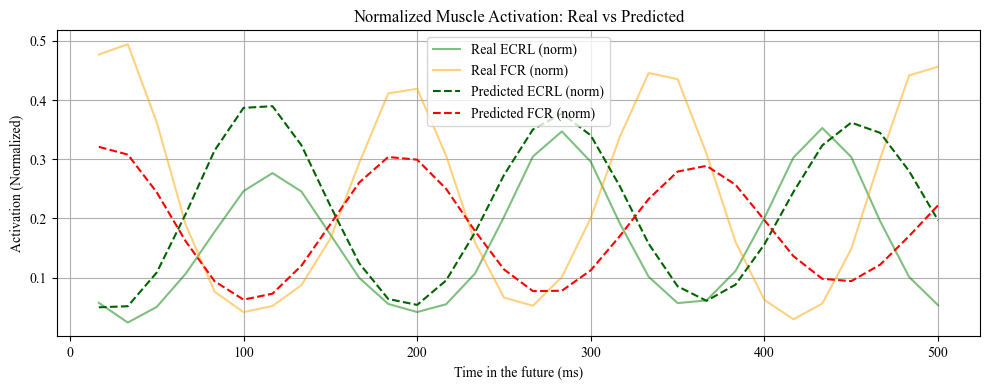

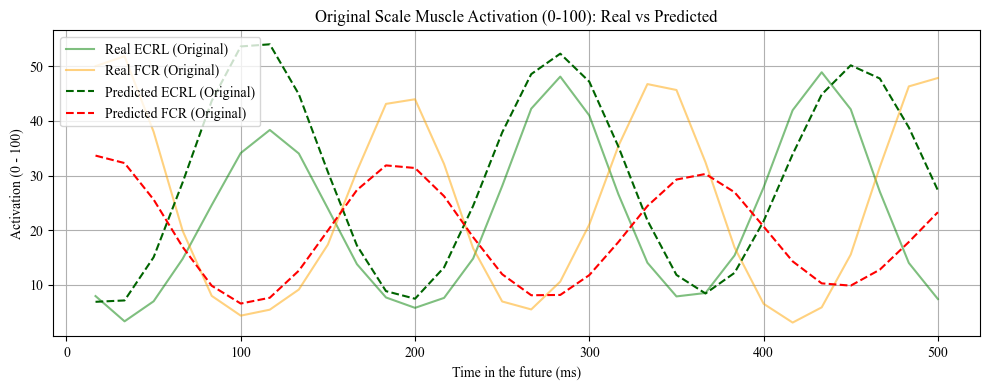

In [ ]:
#Plots datos normalizados y desnormalizados
data_iter = iter(test_loader)
X_real_batch, y_real_batch = next(data_iter)

real_input = X_real_batch[0:1].to(device) 
real_target = y_real_batch[0:1].numpy()  # Guardamos el target real para comparar

model.eval()
with torch.no_grad():
    pred_real = model(real_input)


pred_real_np = pred_real.cpu().numpy()  # Forma: (1, output_len, 2)

future_ms = np.arange(1, output_len + 1) * (1000 / 60)



plt.figure(figsize=(10, 4))
# Canales Reales (Target)
plt.plot(future_ms, real_target[0, :, 0], label='Real ECRL (norm)', color='green', alpha=0.5)
plt.plot(future_ms, real_target[0, :, 1], label='Real FCR (norm)', color='orange', alpha=0.5)
# Canales Predichos
plt.plot(future_ms, pred_real_np[0, :, 0], '--', label='Predicted ECRL (norm)', color='darkgreen')
plt.plot(future_ms, pred_real_np[0, :, 1], '--', label='Predicted FCR (norm)', color='red')

plt.xlabel("Time in the future (ms)")
plt.ylabel("Activation (Normalized)")
plt.title("Normalized Muscle Activation: Real vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Aplanamos a (-1, 2) para el scaler y luego regresamos a la forma original (1, output_len, 2)
pred_real_inv = scaler_output.inverse_transform(pred_real_np.reshape(-1, 2)).reshape(pred_real_np.shape)
target_real_inv = scaler_output.inverse_transform(real_target.reshape(-1, 2)).reshape(real_target.shape)


plt.figure(figsize=(10, 4))
# Canales Reales Desnormalizados
plt.plot(future_ms, target_real_inv[0, :, 0], label='Real ECRL (Original)', color='green', alpha=0.5)
plt.plot(future_ms, target_real_inv[0, :, 1], label='Real FCR (Original)', color='orange', alpha=0.5)
# Canales Predichos Desnormalizados
plt.plot(future_ms, pred_real_inv[0, :, 0], '--', label='Predicted ECRL (Original)', color='darkgreen')
plt.plot(future_ms, pred_real_inv[0, :, 1], '--', label='Predicted FCR (Original)', color='red')

plt.xlabel("Time in the future (ms)")
plt.ylabel("Activation (0 - 100)")
plt.title("Original Scale Muscle Activation (0-100): Real vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Error por time step

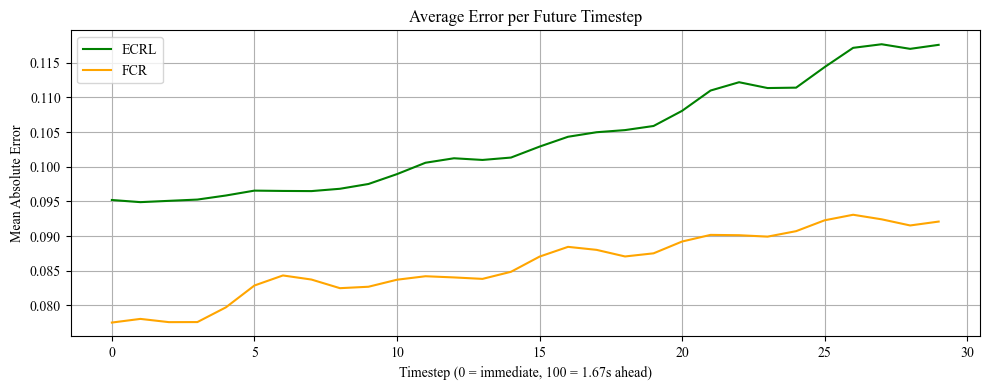

In [21]:
errors = np.abs(y_pred - y_true)
mean_errors = errors.mean(axis=0)

t = np.arange(output_len)
plt.figure(figsize=(10, 4))
plt.plot(t, mean_errors[:, 0], label="ECRL", color='green')
plt.plot(t, mean_errors[:, 1], label="FCR", color='orange')
plt.title("Average Error per Future Timestep")
plt.xlabel("Timestep (0 = immediate, 100 = 1.67s ahead)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show() 

#el errror va aumentando, por que cada vez le cuesta más y acumula errores.

### Debugging

X_train shape: (26851, 60), y_train shape: (26851, 30, 2)
X_val shape: (3796, 60), y_val shape: (3796, 30, 2)
y_train min: 0.0, max: 1.0
Input scaler min: [-4.840764], max: [5.096766]
Output scaler min: [0. 0.], max: [138.69743  104.903915]

📊 Train EMG Prediction:
MAE: 10.3335, RMSE: 14.3913, R²: 0.4087


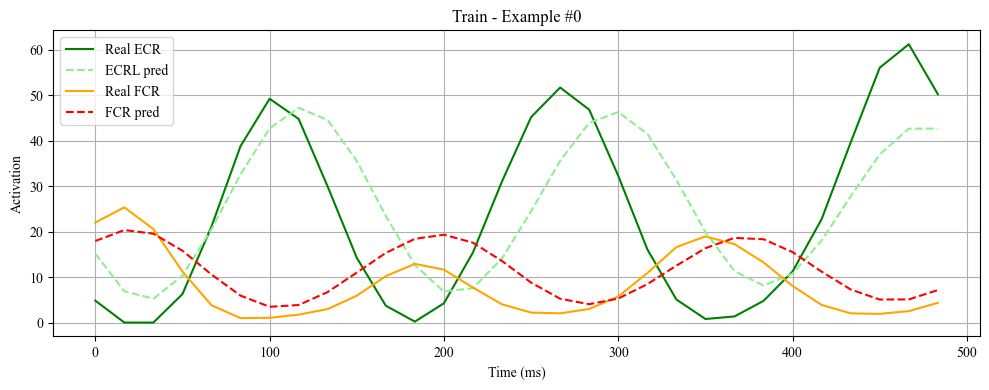

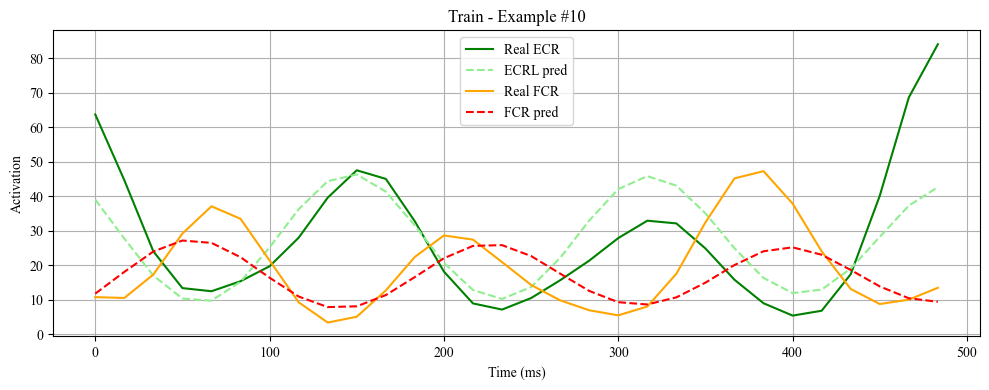

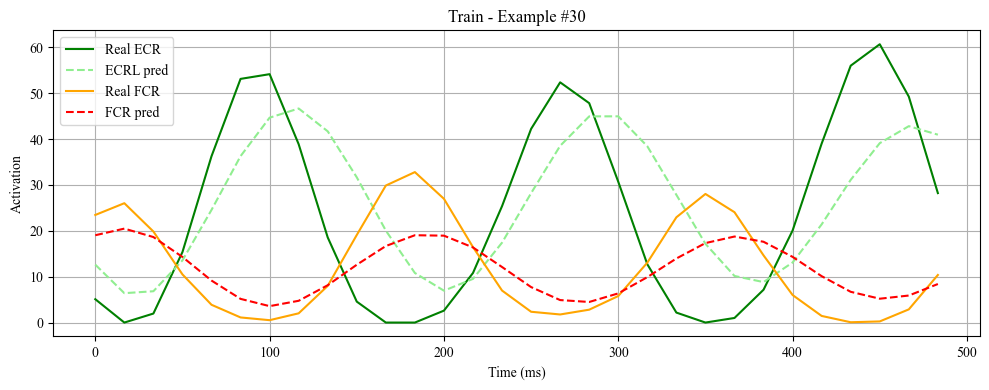

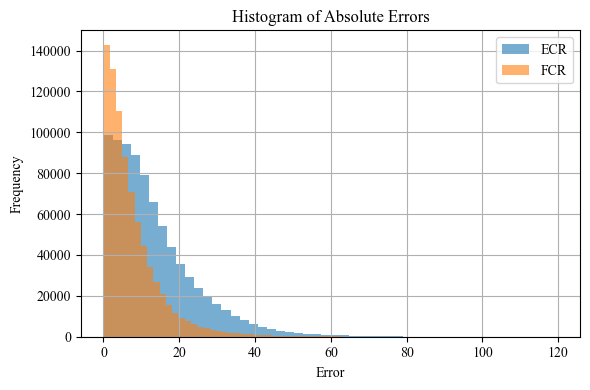

In [22]:

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

print(f"y_train min: {y_train.min()}, max: {y_train.max()}")

print(f"Input scaler min: {scaler_input.data_min_}, max: {scaler_input.data_max_}")
print(f"Output scaler min: {scaler_output.data_min_}, max: {scaler_output.data_max_}")

y_pred_train, y_true_train = evaluate_and_plot(train_loader, "Train")

np.save("test_indices.npy", test_idx)
np.save("train_indices.npy", train_idx)
np.save("val_indices.npy", val_idx)

In [56]:
import os
from pathlib import Path

print("CWD:", os.getcwd())
print("name:", name)
print("RESULTS_DIR (rel):", RESULTS_DIR)
print("RESULTS_DIR (abs):", os.path.abspath(RESULTS_DIR))
print("PTH_DIR (abs):", os.path.abspath(PTH_DIR))

abs_results = Path(os.path.abspath(RESULTS_DIR))
print("RESULTS_DIR exists:", abs_results.exists())
if abs_results.exists():
    files = sorted([p.name for p in abs_results.glob("*")])
    print("Files in RESULTS_DIR:", files[:50])
else:
    print("RESULTS_DIR not found on disk")

CWD: c:\Users\adria\Downloads\Python-IMU\Adriana-Neuroengineering_lab\RNN
name: 701569_epochs_optunafullBIEN
RESULTS_DIR (rel): C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/RNN\GRUact7fullBIEN\701569_epochs_optunafullBIEN
RESULTS_DIR (abs): C:\Users\adria\Downloads\Python-IMU\Adriana-Neuroengineering_lab\RNN\GRUact7fullBIEN\701569_epochs_optunafullBIEN
PTH_DIR (abs): C:\Users\adria\Downloads\Python-IMU\Adriana-Neuroengineering_lab\RNN\GRUpth\best_emg_model_seq_GRU_701569_epochs_optunafullBIEN.pth
RESULTS_DIR exists: True
Files in RESULTS_DIR: ['Boxplot_Errors_Test_701569_epochs_optunafullBIEN.png', 'Boxplot_Errors_Train_701569_epochs_optunafullBIEN.png', 'Error_by_timestep_Test_701569_epochs_optunafullBIEN.png', 'Error_by_timestep_Train_701569_epochs_optunafullBIEN.png', 'Error_mu_sigma_Test_701569_epochs_optunafullBIEN.png', 'Error_mu_sigma_Train_701569_epochs_optunafullBIEN.png', 'Input_output_pair_5_701569_GRUplotsBIEN.png', 'Input_output_pair_Test_5_701569_epoch